# 0. 라이브러리 호출 및 데이터 로드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/여친_TravelMate

In [ ]:
!pip install -U keras-tuner

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from keras_tuner import HyperModel
from keras_tuner.tuners import RandomSearch

from tensorflow.keras.models import load_model

## 데이터 확인

In [ ]:
df = pd.read_csv("Data/Final/final_5.csv")

In [ ]:
handle = ["VISIT_AREA_NM", "VISIT_COUNT", "VISIT_MAIN_REASON", 'VISIT_CHC_REASON_CD', 'VISIT_REASON', "VISIT_AREA_MAIN_TYPE",
          "TRAVELER_ID", "TRAVEL_STYL_1", "TRAVEL_STYL_5", "TRAVEL_STYL_6",
          "TRAVEL_MOTIVE_1", "TRAVEL_MISSION_PRIORITY", "DGSTFN"]

In [ ]:
df = df[handle]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34720 entries, 0 to 34719
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   VISIT_AREA_NM            34720 non-null  object
 1   VISIT_COUNT              34720 non-null  int64 
 2   VISIT_MAIN_REASON        34720 non-null  int64 
 3   VISIT_CHC_REASON_CD      34720 non-null  int64 
 4   VISIT_REASON             34720 non-null  object
 5   VISIT_AREA_MAIN_TYPE     34720 non-null  int64 
 6   TRAVELER_ID              34720 non-null  object
 7   TRAVEL_STYL_1            34720 non-null  int64 
 8   TRAVEL_STYL_5            34720 non-null  int64 
 9   TRAVEL_STYL_6            34720 non-null  int64 
 10  TRAVEL_MOTIVE_1          34720 non-null  int64 
 11  TRAVEL_MISSION_PRIORITY  34720 non-null  int64 
 12  DGSTFN                   34720 non-null  int64 
dtypes: int64(10), object(3)
memory usage: 3.4+ MB


In [ ]:
df

,VISIT_AREA_NM,VISIT_COUNT,VISIT_MAIN_REASON,VISIT_CHC_REASON_CD,VISIT_REASON,VISIT_AREA_MAIN_TYPE,TRAVELER_ID,TRAVEL_STYL_1,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_MOTIVE_1,TRAVEL_MISSION_PRIORITY,DGSTFN
0,산굼부리,99,1,4,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040...",1,d000296,2,5,4,3,2,5
1,산굼부리,99,1,4,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040...",1,d003259,2,2,2,2,22,5
2,산굼부리,99,1,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040...",1,d001522,2,6,6,2,4,5
3,산굼부리,99,1,4,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040...",1,d010245,2,4,4,1,22,5
4,산굼부리,99,1,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040...",1,d003054,4,4,6,3,7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34715,미니K코인노래연습장,1,9,9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",4,d000621,3,4,2,1,6,5
34716,장동민의크라우드pc방,1,9,9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",3,d000621,3,4,2,1,6,5
34717,앤유 피시방,1,4,4,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3,d000621,3,4,2,1,6,5
34718,전주아줌마두루치기,1,9,9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",11,d000621,3,4,2,1,6,5


# 1. 모델 생성

## 1. General NCF

### 데이터 전처리

In [ ]:
data_tmp = handle_df

In [ ]:
# 만족도 데이터의 정규화 (0과 1 사이로 스케일링)
handle_df['DGSTFN'] = (handle_df['DGSTFN'] - handle_df['DGSTFN'].min()) / (handle_df['DGSTFN'].max() - handle_df['DGSTFN'].min())

In [ ]:
# ID를 숫자로 매핑
traveler_id_mapping = {id: idx for idx, id in enumerate(handle_df['TRAVELER_ID'].unique())}
visit_area_mapping = {area: idx for idx, area in enumerate(handle_df['VISIT_AREA_NM'].unique())}

# 매핑을 데이터프레임에 적용
handle_df['TRAVELER_ID_IDX'] = handle_df['TRAVELER_ID'].map(traveler_id_mapping)
handle_df['VISIT_AREA_NM_IDX'] = handle_df['VISIT_AREA_NM'].map(visit_area_mapping)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Train Test Split

In [ ]:
# 데이터프레임을 feature와 target으로 나누기
features = handle_df[['TRAVELER_ID_IDX', 'VISIT_AREA_NM_IDX']]
target = handle_df['DGSTFN']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# 학습 데이터프레임과 테스트 데이터프레임 생성
train_df = pd.DataFrame(X_train)
train_df['DGSTFN'] = y_train.values

test_df = pd.DataFrame(X_test)
test_df['DGSTFN'] = y_test.values

In [ ]:
# 데이터셋 정의
class TravelDataset_G(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            'traveler_id': torch.tensor(row['TRAVELER_ID_IDX'], dtype=torch.long),
            'visit_area_name': torch.tensor(row['VISIT_AREA_NM_IDX'], dtype=torch.long),
            'satisfaction': torch.tensor(row['DGSTFN'], dtype=torch.float).unsqueeze(0)  # 차원 추가
        }

In [ ]:
# NCF 모델 정의
class NCF_G(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=8):
        super(NCF_G, self).__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim * 2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, user, item):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb], dim=-1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x


In [ ]:
# 학습 데이터셋과 테스트 데이터셋 생성
train_dataset = TravelDataset_G(train_df)
test_dataset = TravelDataset_G(test_df)

# 데이터로더 생성
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=2, shuffle=False)

In [ ]:
# 모델 초기화 및 GPU로 이동
n_users = len(traveler_id_mapping)
n_items = len(visit_area_mapping)
model_g = NCF_G(n_users, n_items).to(device)

# 손실 함수, 옵티마이저 초기화
criterion = nn.BCELoss()
optimizer = optim.Adam(model_g.parameters(), lr=0.001)

In [ ]:
# 모델 학습
for epoch in range(5):  # epochs 수 조절
    model_g.train()  # 모델을 학습 모드로 설정
    epoch_loss = 0
    for batch in tqdm(train_dataloader, desc=f'Epoch {epoch+1}', unit='batch'):
        user = batch['traveler_id'].to(device)
        item = batch['visit_area_name'].to(device)
        rating = batch['satisfaction'].to(device)

        optimizer.zero_grad()
        output = model_g(user, item)
        loss = criterion(output, rating)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dataloader)
    print(f'Epoch {epoch+1}, Average Train Loss: {avg_loss:.4f}')

Epoch 1: 100%|██████████| 13888/13888 [00:31<00:00, 442.40batch/s]


Epoch 1, Average Train Loss: 0.4615


Epoch 2: 100%|██████████| 13888/13888 [00:31<00:00, 444.11batch/s]


Epoch 2, Average Train Loss: 0.4478


Epoch 3: 100%|██████████| 13888/13888 [00:31<00:00, 443.95batch/s]


Epoch 3, Average Train Loss: 0.4374


Epoch 4: 100%|██████████| 13888/13888 [00:30<00:00, 448.97batch/s]


Epoch 4, Average Train Loss: 0.4293


Epoch 5: 100%|██████████| 13888/13888 [00:31<00:00, 447.72batch/s]

Epoch 5, Average Train Loss: 0.4226


In [ ]:
# 모델 평가
model_g.eval()  # 모델을 평가 모드로 설정
all_preds = []
all_labels = []

with torch.no_grad():  # 평가 중에는 기울기 계산 비활성화
    for batch in tqdm(test_dataloader, desc='Evaluating', unit='batch'):
        user = batch['traveler_id'].to(device)
        item = batch['visit_area_name'].to(device)
        rating = batch['satisfaction'].to(device)

        output = model_g(user, item)
        preds = output.cpu().numpy()
        labels = rating.cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

# 예측값을 이진 분류로 변환 (임계값 0.5 사용)
binary_preds = [1 if p >= 0.5 else 0 for p in all_preds]
binary_labels = [1 if l >= 0.5 else 0 for l in all_labels]

accuracy = accuracy_score(binary_labels, binary_preds)
f1 = f1_score(binary_labels, binary_preds)

print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')

Evaluating: 100%|██████████| 3472/3472 [00:02<00:00, 1213.86batch/s]

Accuracy: 0.9682
F1 Score: 0.9838


### 모델 예측 함수 정의

In [ ]:
def predict_satisfaction(model, user_id, item_id, device):
    model.eval()  # 모델을 평가 모드로 설정
    with torch.no_grad():
        user_tensor = torch.tensor([user_id], dtype=torch.long).to(device)
        item_tensor = torch.tensor([item_id], dtype=torch.long).to(device)

        # 모델을 통해 예측값 계산
        output = model(user_tensor, item_tensor)

        # 예측값 반환 (예: 확률값)
        return output.item()


In [ ]:
# 모델을 GPU로 이동 (필요한 경우)
model_g = model_g.to(device)

# 만족도 예측
predicted_satisfaction = predict_satisfaction(model_g, user_id, item_id, device)

print(f'Predicted satisfaction for user {user_id} and item {item_id}: {predicted_satisfaction:.4f}')

## 2. Fitted NCF

### 데이터 EDA

In [ ]:
df.columns

Index(['VISIT_AREA_NM', 'VISIT_COUNT', 'VISIT_MAIN_REASON',
       'VISIT_CHC_REASON_CD', 'VISIT_REASON', 'VISIT_AREA_MAIN_TYPE',
       'TRAVELER_ID', 'TRAVEL_STYL_1', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6',
       'TRAVEL_MOTIVE_1', 'TRAVEL_MISSION_PRIORITY', 'DGSTFN'],
      dtype='object')

In [ ]:
df[df["VISIT_COUNT"]<3].shape[0]

6232

In [ ]:
cnt_under_3 = df[df["VISIT_COUNT"]<3]
cnt_under_4 = df[df["VISIT_COUNT"]<4]
cnt_under_5 = df[df["VISIT_COUNT"]<5]
cnt_under_6 = df[df["VISIT_COUNT"]<6]
cnt_under_7 = df[df["VISIT_COUNT"]<7]

per_3 = cnt_under_3[cnt_under_3['DGSTFN']<3]
per_4 = cnt_under_4[cnt_under_4['DGSTFN']<3]
per_5 = cnt_under_5[cnt_under_5['DGSTFN']<3]
per_6 = cnt_under_6[cnt_under_6['DGSTFN']<3]
per_7 = cnt_under_7[cnt_under_7['DGSTFN']<3]

In [ ]:
under_3 = len(df[df['DGSTFN'] < 3])
under_3

1105

In [ ]:
df['DGSTFN'].value_counts()

,count
DGSTFN,
5,16690
4,12557
3,4368
2,785
1,320


In [ ]:
print("Satisfaction under 3: ", under_3)

print("Count under 3, Satisfaction under 3: ", cnt_under_3.shape[0], ", ", per_3.shape[0])
print("Count under 4, Satisfaction under 3: ", cnt_under_4.shape[0], ", ", per_4.shape[0])
print("Count under 5, Satisfaction under 3: ", cnt_under_5.shape[0], ", ", per_5.shape[0])
print("Count under 6, Satisfaction under 3: ", cnt_under_6.shape[0], ", ", per_6.shape[0])
print("Count under 7, Satisfaction under 3: ", cnt_under_7.shape[0], ", ", per_7.shape[0])

Satisfaction under 3:  1105
Count under 3, Satisfaction under 3:  6232 ,  236
Count under 4, Satisfaction under 3:  8383 ,  319
Count under 5, Satisfaction under 3:  10175 ,  402
Count under 6, Satisfaction under 3:  11870 ,  451
Count under 7, Satisfaction under 3:  13022 ,  495


### 데이터 전처리

In [ ]:
S# # 1. VISIT_AREA_NM 별로 VISIT_CHC_REASON_CD의 개수를 계산
# reason_counts = df.groupby(['VISIT_AREA_NM', 'VISIT_CHC_REASON_CD']).size().unstack(fill_value=0)

# # 2. 각 이유에 대한 비율을 계산하고 소수점 6자리로 반올림
# reason_ratios = reason_counts.div(reason_counts.sum(axis=1), axis=0).round(6)

# # 3. VISIT_REASON이라는 열에 비율 리스트를 저장
# df_ratios = reason_ratios.apply(lambda row: row.tolist(), axis=1).reset_index()
# df_ratios.columns = ['VISIT_AREA_NM', 'VISIT_REASON']

In [ ]:
# df_ratios

,VISIT_AREA_NM,VISIT_REASON
0,064노트,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,064바당,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,064푸드트럭,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,104스테이,"[0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, ..."
4,10호어린이공원,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
...,...,...
7593,히츠야,"[0.2, 0.4, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.2, ..."
7594,히포파운드,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7595,힐록,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
7596,힐링스테이,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."


In [ ]:
# merge = pd.merge(df, df_ratios, on = 'VISIT_AREA_NM', how = 'left')
# merge

In [ ]:
# merge.columns

Index(['Unnamed: 0', 'VISIT_AREA_ID', 'TRAVEL_ID', 'VISIT_ORDER',
       'VISIT_AREA_NM', 'VISIT_START_YMD', 'VISIT_END_YMD', 'ROAD_NM_ADDR',
       'LOTNO_ADDR', 'X_COORD', 'Y_COORD', 'ROAD_NM_CD', 'LOTNO_CD', 'POI_ID',
       'POI_NM', 'RESIDENCE_TIME_MIN', 'VISIT_AREA_TYPE_CD', 'REVISIT_YN',
       'VISIT_CHC_REASON_CD', 'LODGING_TYPE_CD', 'DGSTFN', 'REVISIT_INTENTION',
       'RCMDTN_INTENTION', 'SGG_CD', 'TRAVEL_NM', 'TRAVELER_ID',
       'TRAVEL_PURPOSE', 'TRAVEL_START_YMD', 'TRAVEL_END_YMD', 'MVMN_NM',
       'TRAVEL_MISSION', 'TRAVEL_MISSION_CHECK', 'TRAVEL_MISSION_PRIORITY',
       'RESIDENCE_SGG_CD', 'GENDER', 'AGE_GRP', 'EDU_NM', 'EDU_FNSH_SE',
       'MARR_STTS', 'FAMILY_MEMB', 'JOB_NM', 'JOB_ETC', 'INCOME',
       'HOUSE_INCOME', 'TRAVEL_TERM', 'TRAVEL_NUM', 'TRAVEL_LIKE_SIDO_1',
       'TRAVEL_LIKE_SGG_1', 'TRAVEL_LIKE_SIDO_2', 'TRAVEL_LIKE_SGG_2',
       'TRAVEL_LIKE_SIDO_3', 'TRAVEL_LIKE_SGG_3', 'TRAVEL_STYL_1',
       'TRAVEL_STYL_2', 'TRAVEL_STYL_3', 'TRAVEL_STYL_4', 

In [ ]:
# merge = merge.drop('Unnamed: 0', axis = 1)
# merge

,VISIT_AREA_ID,TRAVEL_ID,VISIT_ORDER,VISIT_AREA_NM,VISIT_START_YMD,VISIT_END_YMD,ROAD_NM_ADDR,LOTNO_ADDR,X_COORD,Y_COORD,...,TRAVEL_MOTIVE_2,TRAVEL_MOTIVE_3,TRAVEL_COMPANIONS_NUM,ADDR,RES_CAFE,VISIT_COUNT,VISIT_AREA_MAIN_TYPE,AVG_TIME_MIN,VISIT_MAIN_REASON,VISIT_REASON
0,2208190004,d_d000296,14,산굼부리,2022-08-19 00:00:00,2022-08-19 00:00:00,NaN,제주특별자치도 제주시 조천읍 교래리 166-2,126.693832,33.432574,...,7.0,1.0,3,제주특별자치도 제주시 조천읍 교래리 166-2,2,99,1,60.0,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040..."
1,2210170005,d_d003259,4,산굼부리,2022-10-17 00:00:00,2022-10-17 00:00:00,NaN,제주특별자치도 제주시 조천읍 교래리 166-2,126.693832,33.432574,...,1.0,3.0,1,제주특별자치도 제주시 조천읍 교래리 166-2,2,99,1,60.0,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040..."
2,2209280002,d_d001522,21,산굼부리,2022-09-28 00:00:00,2022-09-28 00:00:00,NaN,제주특별자치도 제주시 조천읍 교래리 166-2,126.693832,33.432574,...,3.0,1.0,5,제주특별자치도 제주시 조천읍 교래리 166-2,2,99,1,60.0,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040..."
3,2211010002,d_d010245,22,산굼부리,2022-11-01 00:00:00,2022-11-01 00:00:00,NaN,제주특별자치도 제주시 조천읍 교래리 166-2,126.693832,33.432574,...,2.0,6.0,1,제주특별자치도 제주시 조천읍 교래리 166-2,2,99,1,60.0,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040..."
4,2210240001,d_d003054,8,산굼부리,2022-10-24 00:00:00,2022-10-24 00:00:00,NaN,제주특별자치도 제주시 조천읍 교래리 166-2,126.693832,33.432574,...,2.0,5.0,1,제주특별자치도 제주시 조천읍 교래리 166-2,2,99,1,60.0,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34715,2208210007,d_d000621,5,미니K코인노래연습장,2022-08-21 00:00:00,2022-08-21 00:00:00,제주특별자치도 제주시 국기로 5,제주특별자치도 제주시 연동 1457,126.490036,33.481279,...,2.0,7.0,1,제주특별자치도 제주시 국기로 5,2,1,4,30.0,9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
34716,2208210008,d_d000621,6,장동민의크라우드pc방,2022-08-21 00:00:00,2022-08-21 00:00:00,제주특별자치도 제주시 건주로4길 10-4,제주특별자치도 제주시 도련일동 1939-3,126.579895,33.516333,...,2.0,7.0,1,제주특별자치도 제주시 건주로4길 10-4,2,1,3,150.0,9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
34717,2208230009,d_d000621,27,앤유 피시방,2022-08-23 00:00:00,2022-08-23 00:00:00,NaN,제주특별자치도 제주시 연동,126.496886,33.488159,...,2.0,7.0,1,제주특별자치도 제주시 연동,2,1,3,210.0,4,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
34718,2208230007,d_d000621,25,전주아줌마두루치기,2022-08-23 00:00:00,2022-08-23 00:00:00,제주특별자치도 제주시 신광로4길 25,제주특별자치도 제주시 연동 251-59,126.487416,33.488756,...,2.0,7.0,1,제주특별자치도 제주시 신광로4길 25,0,1,11,30.0,9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."


In [ ]:
# merge.to_csv('Data/Final/final_5.csv', index = False)

In [ ]:
# check = pd.read_csv('Data/Final/final_5.csv')
# check

,VISIT_AREA_ID,TRAVEL_ID,VISIT_ORDER,VISIT_AREA_NM,VISIT_START_YMD,VISIT_END_YMD,ROAD_NM_ADDR,LOTNO_ADDR,X_COORD,Y_COORD,...,TRAVEL_MOTIVE_2,TRAVEL_MOTIVE_3,TRAVEL_COMPANIONS_NUM,ADDR,RES_CAFE,VISIT_COUNT,VISIT_AREA_MAIN_TYPE,AVG_TIME_MIN,VISIT_MAIN_REASON,VISIT_REASON
0,2208190004,d_d000296,14,산굼부리,2022-08-19 00:00:00,2022-08-19 00:00:00,NaN,제주특별자치도 제주시 조천읍 교래리 166-2,126.693832,33.432574,...,7.0,1.0,3,제주특별자치도 제주시 조천읍 교래리 166-2,2,99,1,60.0,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040..."
1,2210170005,d_d003259,4,산굼부리,2022-10-17 00:00:00,2022-10-17 00:00:00,NaN,제주특별자치도 제주시 조천읍 교래리 166-2,126.693832,33.432574,...,1.0,3.0,1,제주특별자치도 제주시 조천읍 교래리 166-2,2,99,1,60.0,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040..."
2,2209280002,d_d001522,21,산굼부리,2022-09-28 00:00:00,2022-09-28 00:00:00,NaN,제주특별자치도 제주시 조천읍 교래리 166-2,126.693832,33.432574,...,3.0,1.0,5,제주특별자치도 제주시 조천읍 교래리 166-2,2,99,1,60.0,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040..."
3,2211010002,d_d010245,22,산굼부리,2022-11-01 00:00:00,2022-11-01 00:00:00,NaN,제주특별자치도 제주시 조천읍 교래리 166-2,126.693832,33.432574,...,2.0,6.0,1,제주특별자치도 제주시 조천읍 교래리 166-2,2,99,1,60.0,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040..."
4,2210240001,d_d003054,8,산굼부리,2022-10-24 00:00:00,2022-10-24 00:00:00,NaN,제주특별자치도 제주시 조천읍 교래리 166-2,126.693832,33.432574,...,2.0,5.0,1,제주특별자치도 제주시 조천읍 교래리 166-2,2,99,1,60.0,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34715,2208210007,d_d000621,5,미니K코인노래연습장,2022-08-21 00:00:00,2022-08-21 00:00:00,제주특별자치도 제주시 국기로 5,제주특별자치도 제주시 연동 1457,126.490036,33.481279,...,2.0,7.0,1,제주특별자치도 제주시 국기로 5,2,1,4,30.0,9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
34716,2208210008,d_d000621,6,장동민의크라우드pc방,2022-08-21 00:00:00,2022-08-21 00:00:00,제주특별자치도 제주시 건주로4길 10-4,제주특별자치도 제주시 도련일동 1939-3,126.579895,33.516333,...,2.0,7.0,1,제주특별자치도 제주시 건주로4길 10-4,2,1,3,150.0,9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
34717,2208230009,d_d000621,27,앤유 피시방,2022-08-23 00:00:00,2022-08-23 00:00:00,NaN,제주특별자치도 제주시 연동,126.496886,33.488159,...,2.0,7.0,1,제주특별자치도 제주시 연동,2,1,3,210.0,4,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
34718,2208230007,d_d000621,25,전주아줌마두루치기,2022-08-23 00:00:00,2022-08-23 00:00:00,제주특별자치도 제주시 신광로4길 25,제주특별자치도 제주시 연동 251-59,126.487416,33.488756,...,2.0,7.0,1,제주특별자치도 제주시 신광로4길 25,0,1,11,30.0,9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."


In [ ]:
# sangum = df_ratios[df_ratios['VISIT_AREA_NM'] == '산굼부리']
# sangum_reason = sangum['VISIT_REASON'].iloc[0]
# sangum_reason

[0.585859,
 0.131313,
 0.020202,
 0.161616,
 0.040404,
 0.0,
 0.0,
 0.0,
 0.040404,
 0.010101,
 0.010101]

In [ ]:
# 전처리 객체 저장 함수
def save_preprocessors(user_scaler, item_scaler, user_encoder, item_encoder):
    with open('Model/Fitted_NCF_0/user_scaler_1.pkl', 'wb') as f:
        pickle.dump(user_scaler, f)
    with open('Model/Fitted_NCF_0/item_scaler_1.pkl', 'wb') as f:
        pickle.dump(item_scaler, f)
    with open('Model/Fitted_NCF_0/user_encoder_1.pkl', 'wb') as f:
        pickle.dump(user_encoder, f)
    with open('Model/Fitted_NCF_0/item_encoder_1.pkl', 'wb') as f:
        pickle.dump(item_encoder, f)

In [ ]:
def preprocess_data(df):
    user_features = ['TRAVEL_STYL_1', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6',
                     'TRAVEL_MOTIVE_1', 'TRAVEL_MISSION_PRIORITY']
    item_features = ['VISIT_COUNT', 'VISIT_AREA_MAIN_TYPE', 'VISIT_MAIN_REASON', 'VISIT_REASON']

    user_data = df[user_features].copy()
    item_data = df[item_features].copy()

    # 연속형 데이터 스케일링
    user_scaler = MinMaxScaler()
    user_data[['TRAVEL_STYL_1', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6']] = user_scaler.fit_transform(user_data[['TRAVEL_STYL_1', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6']])
    item_scaler = MinMaxScaler()
    item_data[['VISIT_COUNT']] = item_scaler.fit_transform(item_data[['VISIT_COUNT']])

    # 범주형 데이터 인코딩
    user_encoder = OneHotEncoder(sparse_output=False)
    user_data_encoded = user_encoder.fit_transform(user_data[['TRAVEL_MOTIVE_1', 'TRAVEL_MISSION_PRIORITY']])

    item_encoder = OneHotEncoder(sparse_output=False)
    item_data_encoded = item_encoder.fit_transform(item_data[['VISIT_AREA_MAIN_TYPE']])

    # VISIT_REASON이 문자열이 아닌 리스트 또는 벡터 형태로 존재하는지 확인
    if isinstance(item_data['VISIT_REASON'].iloc[0], str):
        # VISIT_REASON이 문자열로 저장되어 있다면, 이를 리스트로 변환 (필요한 경우)
        item_data['VISIT_REASON'] = item_data['VISIT_REASON'].apply(lambda x: eval(x) if isinstance(x, str) else x)

    # VISIT_REASON 벡터를 VISIT_REASON_1, VISIT_REASON_2, ...으로 분리하여 데이터프레임으로 변환
    visit_reason_columns = [f'VISIT_REASON_{i+1}' for i in range(len(item_data['VISIT_REASON'].iloc[0]))]
    visit_reason_df = pd.DataFrame(item_data['VISIT_REASON'].tolist(), columns=visit_reason_columns)

    # 인코딩된 item_data_encoded와 VISIT_REASON 데이터를 병합
    item_data_encoded_df = pd.DataFrame(item_data_encoded, columns=item_encoder.get_feature_names_out(['VISIT_AREA_MAIN_TYPE']))
    item_data_final = pd.concat([item_data[['VISIT_COUNT']], item_data_encoded_df, visit_reason_df], axis=1)

    # 인코딩된 user_data를 데이터프레임으로 변환
    user_data_encoded_df = pd.DataFrame(user_data_encoded, columns=user_encoder.get_feature_names_out(['TRAVEL_MOTIVE_1', 'TRAVEL_MISSION_PRIORITY']))

    # 원래 데이터와 인코딩된 데이터를 병합
    user_data_final = pd.concat([user_data[['TRAVEL_STYL_1', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6']], user_data_encoded_df], axis=1)

    save_preprocessors(user_scaler, item_scaler, user_encoder, item_encoder)

    return user_data_final, item_data_final

In [ ]:
# 함수 적용
user_data, item_data = preprocess_data(df)
label_data = df[["DGSTFN"]]

In [ ]:
user_data

,TRAVEL_STYL_1,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_MOTIVE_1_1,TRAVEL_MOTIVE_1_2,TRAVEL_MOTIVE_1_3,TRAVEL_MOTIVE_1_4,TRAVEL_MOTIVE_1_5,TRAVEL_MOTIVE_1_6,TRAVEL_MOTIVE_1_7,...,TRAVEL_MISSION_PRIORITY_12,TRAVEL_MISSION_PRIORITY_13,TRAVEL_MISSION_PRIORITY_21,TRAVEL_MISSION_PRIORITY_22,TRAVEL_MISSION_PRIORITY_23,TRAVEL_MISSION_PRIORITY_24,TRAVEL_MISSION_PRIORITY_25,TRAVEL_MISSION_PRIORITY_26,TRAVEL_MISSION_PRIORITY_27,TRAVEL_MISSION_PRIORITY_28
0,0.166667,0.666667,0.500000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.166667,0.166667,0.166667,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.166667,0.833333,0.833333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.166667,0.500000,0.500000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.500000,0.500000,0.833333,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34715,0.333333,0.500000,0.166667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34716,0.333333,0.500000,0.166667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34717,0.333333,0.500000,0.166667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34718,0.333333,0.500000,0.166667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
user_data.columns

Index(['TRAVEL_STYL_1', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6', 'TRAVEL_MOTIVE_1_1',
       'TRAVEL_MOTIVE_1_2', 'TRAVEL_MOTIVE_1_3', 'TRAVEL_MOTIVE_1_4',
       'TRAVEL_MOTIVE_1_5', 'TRAVEL_MOTIVE_1_6', 'TRAVEL_MOTIVE_1_7',
       'TRAVEL_MOTIVE_1_8', 'TRAVEL_MOTIVE_1_9', 'TRAVEL_MOTIVE_1_10',
       'TRAVEL_MISSION_PRIORITY_1', 'TRAVEL_MISSION_PRIORITY_2',
       'TRAVEL_MISSION_PRIORITY_3', 'TRAVEL_MISSION_PRIORITY_4',
       'TRAVEL_MISSION_PRIORITY_5', 'TRAVEL_MISSION_PRIORITY_6',
       'TRAVEL_MISSION_PRIORITY_7', 'TRAVEL_MISSION_PRIORITY_8',
       'TRAVEL_MISSION_PRIORITY_9', 'TRAVEL_MISSION_PRIORITY_10',
       'TRAVEL_MISSION_PRIORITY_11', 'TRAVEL_MISSION_PRIORITY_12',
       'TRAVEL_MISSION_PRIORITY_13', 'TRAVEL_MISSION_PRIORITY_21',
       'TRAVEL_MISSION_PRIORITY_22', 'TRAVEL_MISSION_PRIORITY_23',
       'TRAVEL_MISSION_PRIORITY_24', 'TRAVEL_MISSION_PRIORITY_25',
       'TRAVEL_MISSION_PRIORITY_26', 'TRAVEL_MISSION_PRIORITY_27',
       'TRAVEL_MISSION_PRIORITY_28'],
      dtype

In [ ]:
item_data

,VISIT_COUNT,VISIT_AREA_MAIN_TYPE_1,VISIT_AREA_MAIN_TYPE_2,VISIT_AREA_MAIN_TYPE_3,VISIT_AREA_MAIN_TYPE_4,VISIT_AREA_MAIN_TYPE_5,VISIT_AREA_MAIN_TYPE_6,VISIT_AREA_MAIN_TYPE_7,VISIT_AREA_MAIN_TYPE_8,VISIT_AREA_MAIN_TYPE_10,...,VISIT_REASON_2,VISIT_REASON_3,VISIT_REASON_4,VISIT_REASON_5,VISIT_REASON_6,VISIT_REASON_7,VISIT_REASON_8,VISIT_REASON_9,VISIT_REASON_10,VISIT_REASON_11
0,0.224256,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.131313,0.020202,0.161616,0.040404,0.0,0.0,0.0,0.040404,0.010101,0.010101
1,0.224256,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.131313,0.020202,0.161616,0.040404,0.0,0.0,0.0,0.040404,0.010101,0.010101
2,0.224256,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.131313,0.020202,0.161616,0.040404,0.0,0.0,0.0,0.040404,0.010101,0.010101
3,0.224256,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.131313,0.020202,0.161616,0.040404,0.0,0.0,0.0,0.040404,0.010101,0.010101
4,0.224256,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.131313,0.020202,0.161616,0.040404,0.0,0.0,0.0,0.040404,0.010101,0.010101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34715,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,0.000000,0.000000
34716,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,0.000000,0.000000
34717,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
34718,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,0.000000,0.000000


In [ ]:
item_data.columns

Index(['VISIT_COUNT', 'VISIT_AREA_MAIN_TYPE_1', 'VISIT_AREA_MAIN_TYPE_2',
       'VISIT_AREA_MAIN_TYPE_3', 'VISIT_AREA_MAIN_TYPE_4',
       'VISIT_AREA_MAIN_TYPE_5', 'VISIT_AREA_MAIN_TYPE_6',
       'VISIT_AREA_MAIN_TYPE_7', 'VISIT_AREA_MAIN_TYPE_8',
       'VISIT_AREA_MAIN_TYPE_10', 'VISIT_AREA_MAIN_TYPE_11',
       'VISIT_AREA_MAIN_TYPE_13', 'VISIT_AREA_MAIN_TYPE_24', 'VISIT_REASON_1',
       'VISIT_REASON_2', 'VISIT_REASON_3', 'VISIT_REASON_4', 'VISIT_REASON_5',
       'VISIT_REASON_6', 'VISIT_REASON_7', 'VISIT_REASON_8', 'VISIT_REASON_9',
       'VISIT_REASON_10', 'VISIT_REASON_11'],
      dtype='object')

### 모델 구현

In [ ]:
def create_fitted_ncf_model(num_user_features, num_item_features):
    # Define the input layers
    user_input = Input(shape=(num_user_features,), name='user_input')
    item_input = Input(shape=(num_item_features,), name='item_input')

    # Define user and item layers
    user_layer = Dense(64, activation='relu', name='user_dense')(user_input)
    user_layer = Dropout(0.5, name='user_dropout')(user_layer)

    item_layer = Dense(64, activation='relu', name='item_dense')(item_input)
    item_layer = Dropout(0.5, name='item_dropout')(item_layer)

    # Concatenate user and item layers
    concat_layer = Concatenate()([user_layer, item_layer])

    # Add dense layers
    dense_1 = Dense(128, activation='relu', name='dense_1')(concat_layer)
    dropout_1 = Dropout(0.3, name='dropout_1')(dense_1)
    dense_2 = Dense(64, activation='relu', name='dense_2')(dropout_1)
    dropout_2 = Dropout(0.3, name='dropout_2')(dense_2)
    output = Dense(1, activation='linear', name='output')(dropout_2)

    # Create the model
    model = Model(inputs=[user_input, item_input], outputs=output)

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    return model

In [ ]:
# 사용자 및 아이템 수 계산
num_user_features = len(user_data.columns)
num_item_features = len(item_data.columns)

# 모델 생성
model = create_fitted_ncf_model(num_user_features, num_item_features)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)   │ (None, 34)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_input (InputLayer)   │ (None, 24)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ user_dense (Dense)        │ (None, 64)             │          2,240 │ user_input[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_dense (Dense)        │ (None, 64)             │          1,600 │ item_input[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ user_dropout (Dropout)    │ (None, 64)             │              0 │ user_dense[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_dropout (Dropout)    │ (None, 64)             │              0 │ item_dense[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 128)            │              0 │ user_dropout[0][0],    │
│                           │                        │                │ item_dropout[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 128)            │         16,512 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 128)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 64)             │          8,256 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 64)             │              0 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ output (Dense)            │ (None, 1)              │             65 │ dropout_2[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 28,673 (112.00 KB)

 Trainable params: 28,673 (112.00 KB)

 Non-trainable params: 0 (0.00 B)

#### HyperModel 클래스 정의

In [ ]:
class NCFHyperModel(HyperModel):
    def __init__(self, num_user_features, num_item_features):
        self.num_user_features = num_user_features
        self.num_item_features = num_item_features

    def build(self, hp):
        # Define the input layers
        user_input = Input(shape=(self.num_user_features,), name='user_input')
        item_input = Input(shape=(self.num_item_features,), name='item_input')

        # Define user and item layers with tunable number of units
        user_layer = Dense(hp.Int('user_units', min_value=32, max_value=128, step=32),
                           activation='relu', name='user_dense')(user_input)
        user_layer = Dropout(hp.Float('user_dropout', min_value=0.2, max_value=0.5, step=0.1),
                             name='user_dropout')(user_layer)

        item_layer = Dense(hp.Int('item_units', min_value=32, max_value=128, step=32),
                           activation='relu', name='item_dense')(item_input)
        item_layer = Dropout(hp.Float('item_dropout', min_value=0.2, max_value=0.5, step=0.1),
                             name='item_dropout')(item_layer)

        # Concatenate user and item layers
        concat_layer = Concatenate()([user_layer, item_layer])

        # Add dense layers with tunable units and dropout rates
        dense_1 = Dense(hp.Int('dense_1_units', min_value=64, max_value=256, step=64),
                        activation='relu', name='dense_1')(concat_layer)
        dropout_1 = Dropout(hp.Float('dropout_1_rate', min_value=0.2, max_value=0.5, step=0.1),
                            name='dropout_1')(dense_1)
        dense_2 = Dense(hp.Int('dense_2_units', min_value=32, max_value=128, step=32),
                        activation='relu', name='dense_2')(dropout_1)
        dropout_2 = Dropout(hp.Float('dropout_2_rate', min_value=0.2, max_value=0.5, step=0.1),
                            name='dropout_2')(dense_2)
        output = Dense(1, activation='linear', name='output')(dropout_2)

        # Create the model
        model = Model(inputs=[user_input, item_input], outputs=output)

        # Compile the model with tunable learning rate
        model.compile(optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')),
                      loss='mse',
                      metrics=['mae'])

        return model


#### Keras Tuner 설정 및 최적의 모델 탐색

In [ ]:
# 사용자 및 아이템 수 계산
num_user_features = len(user_data.columns)
num_item_features = len(item_data.columns)

# HyperModel 인스턴스 생성
ncf_hypermodel = NCFHyperModel(num_user_features, num_item_features)

# RandomSearch 튜너 생성
tuner = RandomSearch(
    ncf_hypermodel,
    objective='val_mae',  # 검증 손실로 최적화
    max_trials=10,        # 시도할 하이퍼파라미터 조합 수
    executions_per_trial=2,  # 각 조합을 몇 번 실행할지
    directory='ncf_tuning',  # 결과 저장 폴더
    project_name='ncf_model'
)

# 데이터 분리
user_train, user_test, item_train, item_test, label_train, label_test = train_test_split(
    user_data, item_data, label_data, test_size=0.2, random_state=10
)

# 튜닝 시작
tuner.search([user_train, item_train], label_train, epochs=20, batch_size=32, validation_split=0.2)

# 최적의 모델 찾기
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

Trial 10 Complete [00h 01m 19s]
val_mae: 0.6787102520465851

Best val_mae So Far: 0.6499123275279999
Total elapsed time: 00h 12m 30s


/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)   │ (None, 34)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_input (InputLayer)   │ (None, 24)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ user_dense (Dense)        │ (None, 96)             │          3,360 │ user_input[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_dense (Dense)        │ (None, 32)             │            800 │ item_input[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ user_dropout (Dropout)    │ (None, 96)             │              0 │ user_dense[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_dropout (Dropout)    │ (None, 32)             │              0 │ item_dense[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 128)            │              0 │ user_dropout[0][0],    │
│                           │                        │                │ item_dropout[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 256)            │         33,024 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 256)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 64)             │         16,448 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 64)             │              0 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ output (Dense)            │ (None, 1)              │             65 │ dropout_2[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 53,697 (209.75 KB)

 Trainable params: 53,697 (209.75 KB)

 Non-trainable params: 0 (0.00 B)

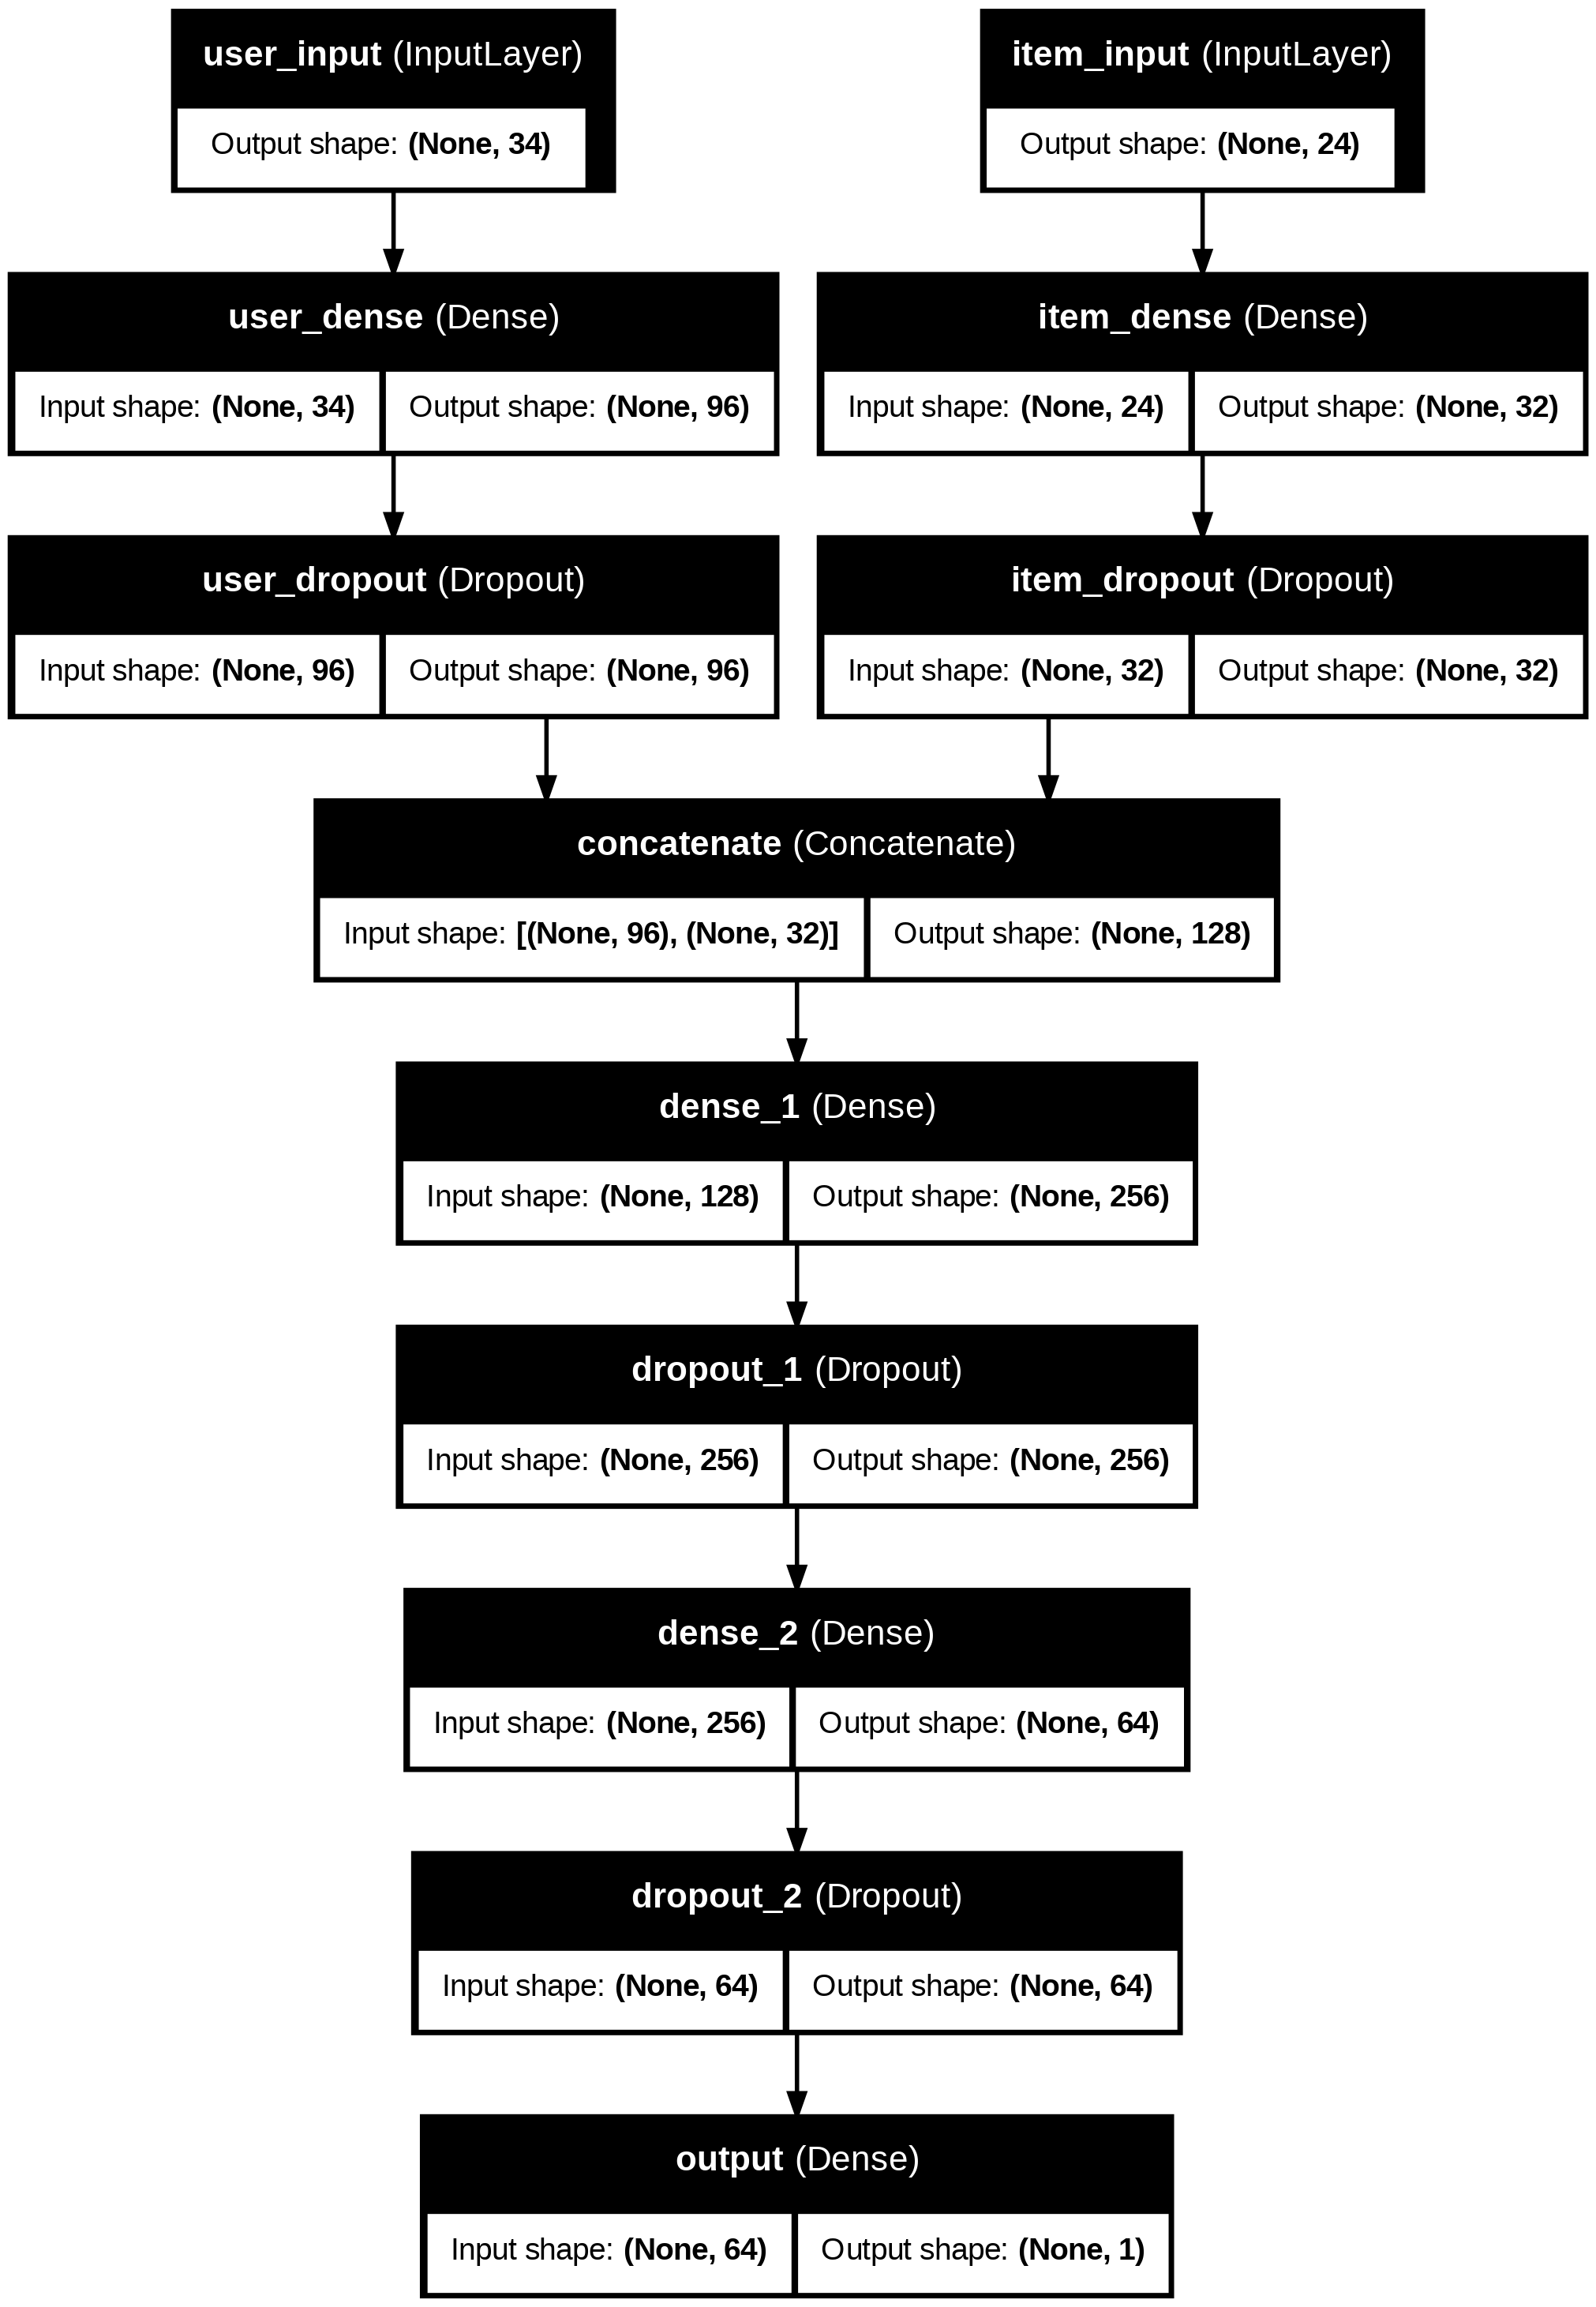

In [ ]:
# 모델 구조를 이미지로 저장
plot_model(best_model, to_file='Model/Structure/best_model_structure_00.png', show_shapes=True, show_layer_names=True)

#### 최적 모델 평가

In [ ]:
# 최적의 모델로 테스트 데이터 평가
test_loss, test_mae = best_model.evaluate([user_test, item_test], label_test)
print(f"Test MAE: {test_mae}")

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6541 - mae: 0.6434
Test MAE: 0.6503444314002991


#### 최적의 하이퍼파라미터 조회

In [ ]:
# 최적의 하이퍼파라미터 출력
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
Optimal number of units for user_dense: {best_hps.get('user_units')}
Optimal number of units for item_dense: {best_hps.get('item_units')}
Optimal number of units for dense_1: {best_hps.get('dense_1_units')}
Optimal number of units for dense_2: {best_hps.get('dense_2_units')}
Optimal learning rate: {best_hps.get('learning_rate')}
""")


Optimal number of units for user_dense: 96
Optimal number of units for item_dense: 32
Optimal number of units for dense_1: 256
Optimal number of units for dense_2: 64
Optimal learning rate: 0.001687289391829868



#### 튜닝 후 결과 데이터 가져오기

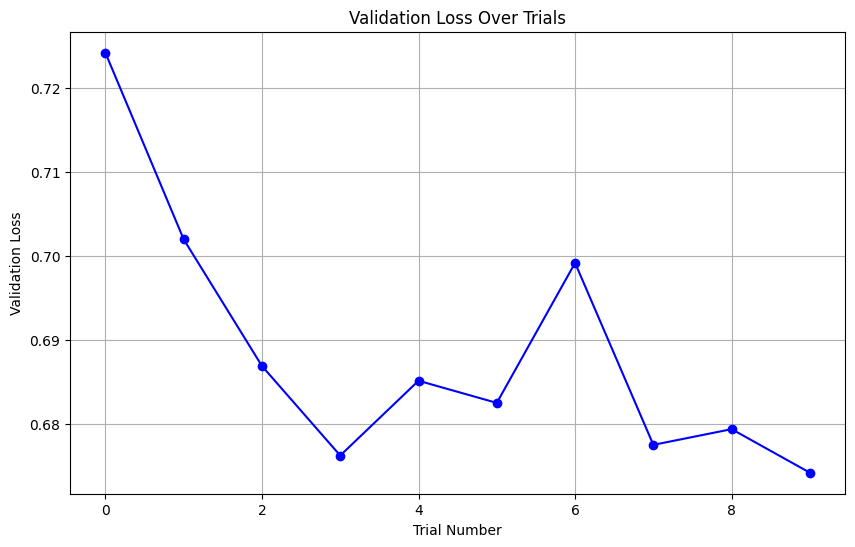

In [ ]:
# 모든 trial의 결과를 DataFrame으로 변환
trials = tuner.oracle.trials.values()  # 모든 trial 가져오기

# trial_id로 정렬 (내림차순으로 정렬하여 최근 trial이 먼저 오도록)
# 어떤 이유에서인지 순서가 반대로 저장되어 있음
trials = sorted(trials, key=lambda x: x.trial_id, reverse=True)

# 각 trial의 hyperparameters와 metrics 저장
results = []
for trial in trials:
    trial_data = trial.hyperparameters.values.copy()  # hyperparameters 가져오기
    trial_data["val_loss"] = trial.metrics.get_best_value("val_loss")  # val_loss 추가
    results.append(trial_data)

# DataFrame 생성
df = pd.DataFrame(results)

# val_loss의 변화를 시각화
plt.figure(figsize=(10, 6))
plt.plot(df['val_loss'], marker='o', linestyle='-', color='b')
plt.title('Validation Loss Over Trials')
plt.xlabel('Trial Number')
plt.ylabel('Validation Loss')
plt.grid(True)
plt.show()

### 모델 학습

In [ ]:
# 최적의 하이퍼파라미터를 가져오기
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

# 최적의 하이퍼파라미터로 모델 빌드
model = ncf_hypermodel.build(best_hp)

# 최적의 모델을 학습
history = model.fit(
    [user_train, item_train],
    label_train,
    epochs=17,  # 필요에 따라 조정
    batch_size=32,  # 필요에 따라 조정
    validation_split=0.2
)

# 학습 후 모델 평가
test_loss, test_mae = model.evaluate([user_test, item_test], label_test)

print(f"Test Loss: {test_loss}")
print(f"Test MAE: {test_mae}")

Epoch 1/17
695/695 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 2.2067 - mae: 1.1134 - val_loss: 0.7316 - val_mae: 0.6891
Epoch 2/17
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1004 - mae: 0.8357 - val_loss: 0.6978 - val_mae: 0.6702
Epoch 3/17
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9869 - mae: 0.7887 - val_loss: 0.7828 - val_mae: 0.7132
Epoch 4/17
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9172 - mae: 0.7624 - val_loss: 0.7012 - val_mae: 0.6723
Epoch 5/17
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8516 - mae: 0.7334 - val_loss: 0.6977 - val_mae: 0.6692
Epoch 6/17
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8278 - mae: 0.7226 - val_loss: 0.6907 - val_mae: 0.6678
Epoch 7/17
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7847 - mae: 0.7036 - val_loss: 0.6807 - val_mae: 0.6576
Epoch 8/17
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7550 - mae: 0.6924 - val_loss: 0.6846 - val_mae: 0.6608
Epoch 9/17
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

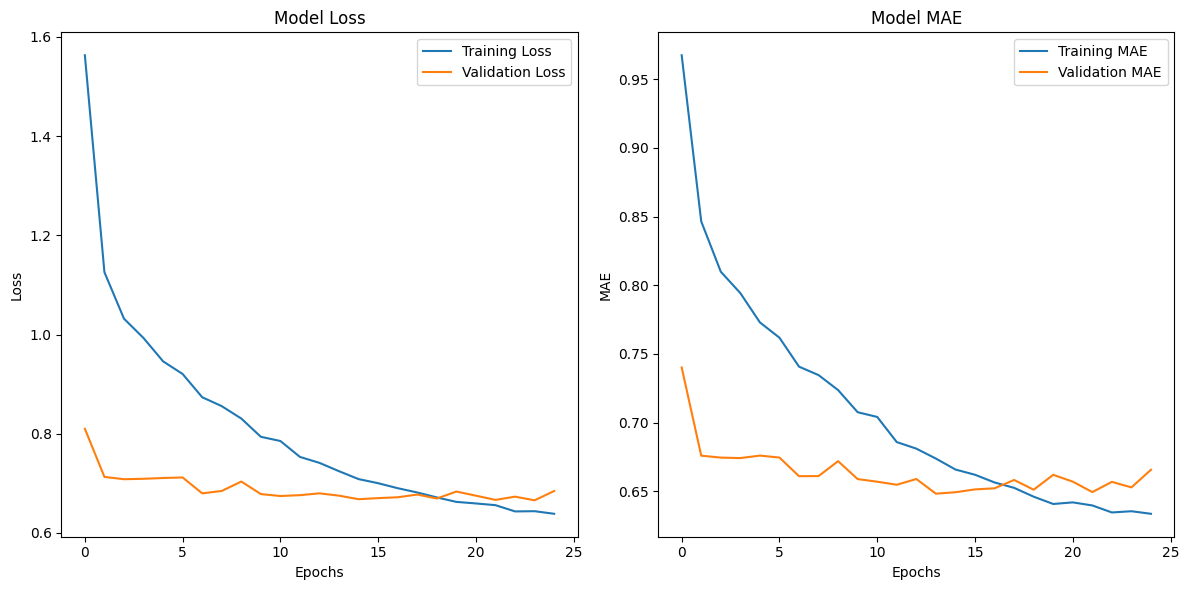

In [ ]:
# 1. 학습 과정의 손실 값(Loss) 시각화
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 2. 학습 과정의 평가 지표(Metrics) 시각화
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)   │ (None, 34)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_input (InputLayer)   │ (None, 24)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ user_dense (Dense)        │ (None, 96)             │          3,360 │ user_input[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_dense (Dense)        │ (None, 32)             │            800 │ item_input[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ user_dropout (Dropout)    │ (None, 96)             │              0 │ user_dense[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_dropout (Dropout)    │ (None, 32)             │              0 │ item_dense[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 128)            │              0 │ user_dropout[0][0],    │
│ (Concatenate)             │                        │                │ item_dropout[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 256)            │         33,024 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 256)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 64)             │         16,448 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 64)             │              0 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ output (Dense)            │ (None, 1)              │             65 │ dropout_2[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 161,093 (629.27 KB)

 Trainable params: 53,697 (209.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 107,396 (419.52 KB)

In [ ]:
model.save('Model/Fitted_NCF_0/fitted_ncf_best_model_00.keras')

### 추측 함수

In [ ]:
# 유저와 아이템의 특성 열 정의
user_features = ['TRAVEL_STYL_1', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6', 'TRAVEL_MOTIVE_1', 'TRAVEL_MISSION_PRIORITY']
item_features = ['VISIT_COUNT', 'VISIT_AREA_MAIN_TYPE', 'VISIT_REASON']

# 전체 열 정의
columns = user_features + item_features

# 빈 데이터프레임 생성
INPUT = pd.DataFrame(columns=columns)

# 데이터 입력 함수
def input_data(user_input, item_input):
    if len(user_input) != len(user_features) or len(item_input) != len(item_features):
        raise ValueError("Input length does not match the expected number of features.")

    # 유저 특성 입력
    user_data = dict(zip(user_features, user_input))

    # 아이템 특성 입력
    item_data = dict(zip(item_features, item_input))

    # 입력받은 데이터를 하나의 딕셔너리로 합침
    data = {**user_data, **item_data}

    # 데이터프레임에 추가
    global INPUT
    new_row = pd.DataFrame([data], columns=columns)
    INPUT = pd.concat([INPUT, new_row], ignore_index=True)

    # 결과 출력
    print("\nUpdated DataFrame:")
    print(INPUT)

#### 예시

In [ ]:
# 함수 실행 예시
user_input = [1, 2, 7, 2, 6] # 자연 친화적 INPUT 예시
item_input = [99, 1, [0.585859,
 0.131313,
 0.020202,
 0.161616,
 0.040404,
 0.0,
 0.0,
 0.0,
 0.040404,
 0.010101,
 0.010101]] # 자연 관광지 INPUT(산굼부리)

# 함수 실행 예시
input_data(user_input, item_input)


Updated DataFrame:
  TRAVEL_STYL_1 TRAVEL_STYL_5 TRAVEL_STYL_6 TRAVEL_MOTIVE_1  \
0             1             2             7               2   

  TRAVEL_MISSION_PRIORITY VISIT_COUNT VISIT_AREA_MAIN_TYPE  \
0                       6          99                    1   

                                        VISIT_REASON  
0  [0.585859, 0.131313, 0.020202, 0.161616, 0.040...  


In [ ]:
INPUT

,TRAVEL_STYL_1,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_MOTIVE_1,TRAVEL_MISSION_PRIORITY,VISIT_COUNT,VISIT_AREA_MAIN_TYPE,VISIT_REASON
0,1,2,7,2,6,99,1,"[0.585859, 0.131313, 0.020202, 0.161616, 0.040..."


In [ ]:
# 전처리 객체 불러오기 함수
def load_preprocessors():
    with open('Model/Fitted_NCF_0/user_scaler_1.pkl', 'rb') as f:
        user_scaler = pickle.load(f)
    with open('Model/Fitted_NCF_0/item_scaler_1.pkl', 'rb') as f:
        item_scaler = pickle.load(f)
    with open('Model/Fitted_NCF_0/user_encoder_1.pkl', 'rb') as f:
        user_encoder = pickle.load(f)
    with open('Model/Fitted_NCF_0/item_encoder_1.pkl', 'rb') as f:
        item_encoder = pickle.load(f)
    return user_scaler, item_scaler, user_encoder, item_encoder

In [ ]:
# 연속형 데이터 스케일링 함수
def min_max_scaling(df, scaler, columns):
    df[columns] = scaler.transform(df[columns])
    return df

# 범주형 데이터 인코딩 함수
def one_hot_encode_columns(df, encoder, columns):
    # 인코딩할 컬럼이 데이터프레임에 모두 존재하는지 확인
    if not all(col in df.columns for col in columns):
        missing_cols = [col for col in columns if col not in df.columns]
        raise ValueError(f"다음 컬럼이 데이터프레임에 존재하지 않습니다: {missing_cols}")

    # 인코딩된 데이터프레임 생성
    encoded_array = encoder.transform(df[columns])
    encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(columns), index=df.index)

    # 원래 데이터프레임에서 인코딩된 컬럼 제거 후 인코딩된 컬럼 추가
    df = df.drop(columns=columns)
    df = pd.concat([df, encoded_df], axis=1)

    return df

In [ ]:
# INPUT 전처리 함수 정의
def preprocess_input_data(df):
    user_features = ['TRAVEL_STYL_1', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6', 'TRAVEL_MOTIVE_1', 'TRAVEL_MISSION_PRIORITY']
    item_features = ['VISIT_COUNT', 'VISIT_AREA_MAIN_TYPE', 'VISIT_REASON']

    # user_data와 item_data 분리
    user_data = INPUT[user_features].copy()
    item_data = INPUT[item_features].copy()

    # 전처리 객체 불러오기
    user_scaler, item_scaler, user_encoder, item_encoder = load_preprocessors()

    # 연속형 데이터 처리
    for col in ['TRAVEL_STYL_1', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6']:
        # 각 컬럼에 대해 수동으로 스케일링 적용
        min_val = user_scaler.data_min_[user_data.columns.get_loc(col)]
        max_val = user_scaler.data_max_[user_data.columns.get_loc(col)]

        # Min-Max Scaling 공식 적용
        user_data[col] = (user_data[col] - min_val) / (max_val - min_val)

    # item_data에 대한 스케일링
    min_val_item = item_scaler.data_min_[item_data.columns.get_loc('VISIT_COUNT')]
    max_val_item = item_scaler.data_max_[item_data.columns.get_loc('VISIT_COUNT')]
    item_data['VISIT_COUNT'] = (item_data['VISIT_COUNT'] - min_val_item) / (max_val_item - min_val_item)

    # 범주형 데이터 처리
    user_cat_columns = ['TRAVEL_MOTIVE_1', 'TRAVEL_MISSION_PRIORITY']
    user_data = one_hot_encode_columns(user_data, user_encoder, user_cat_columns)

    item_cat_columns = ['VISIT_AREA_MAIN_TYPE']
    item_data = one_hot_encode_columns(item_data, item_encoder, item_cat_columns)

    # VISIT_REASON이 문자열이 아닌 리스트 또는 벡터 형태로 존재하는지 확인
    if isinstance(item_data['VISIT_REASON'].iloc[0], str):
        # VISIT_REASON이 문자열로 저장되어 있다면, 이를 리스트로 변환 (필요한 경우)
        item_data['VISIT_REASON'] = item_data['VISIT_REASON'].apply(lambda x: eval(x) if isinstance(x, str) else x)

    # VISIT_REASON 벡터를 VISIT_REASON_1, VISIT_REASON_2, ...으로 분리하여 데이터프레임으로 변환
    visit_reason_columns = [f'VISIT_REASON_{i+1}' for i in range(len(item_data['VISIT_REASON'].iloc[0]))]
    visit_reason_df = pd.DataFrame(item_data['VISIT_REASON'].tolist(), columns=visit_reason_columns)

    # Join, Drop
    item_data = item_data.join(visit_reason_df)
    item_data = item_data.drop('VISIT_REASON', axis = 1)

    return user_data, item_data

In [ ]:
user_pre, item_pre = preprocess_input_data(INPUT)

In [ ]:
user_pre

,TRAVEL_STYL_1,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_MOTIVE_1_1,TRAVEL_MOTIVE_1_2,TRAVEL_MOTIVE_1_3,TRAVEL_MOTIVE_1_4,TRAVEL_MOTIVE_1_5,TRAVEL_MOTIVE_1_6,TRAVEL_MOTIVE_1_7,...,TRAVEL_MISSION_PRIORITY_12,TRAVEL_MISSION_PRIORITY_13,TRAVEL_MISSION_PRIORITY_21,TRAVEL_MISSION_PRIORITY_22,TRAVEL_MISSION_PRIORITY_23,TRAVEL_MISSION_PRIORITY_24,TRAVEL_MISSION_PRIORITY_25,TRAVEL_MISSION_PRIORITY_26,TRAVEL_MISSION_PRIORITY_27,TRAVEL_MISSION_PRIORITY_28
0,0.0,0.166667,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
item_pre

,VISIT_COUNT,VISIT_AREA_MAIN_TYPE_1,VISIT_AREA_MAIN_TYPE_2,VISIT_AREA_MAIN_TYPE_3,VISIT_AREA_MAIN_TYPE_4,VISIT_AREA_MAIN_TYPE_5,VISIT_AREA_MAIN_TYPE_6,VISIT_AREA_MAIN_TYPE_7,VISIT_AREA_MAIN_TYPE_8,VISIT_AREA_MAIN_TYPE_10,...,VISIT_REASON_2,VISIT_REASON_3,VISIT_REASON_4,VISIT_REASON_5,VISIT_REASON_6,VISIT_REASON_7,VISIT_REASON_8,VISIT_REASON_9,VISIT_REASON_10,VISIT_REASON_11
0,0.224256,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.131313,0.020202,0.161616,0.040404,0.0,0.0,0.0,0.040404,0.010101,0.010101


In [ ]:
def predict_result(model, input):
    # 전처리
    user_input, item_input = preprocess_input_data(input)

    # 예측
    prediction = model.predict([user_input, item_input])
    return prediction

In [ ]:
result = predict_result(loaded_model, INPUT)
print(result[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
4.2202864
